2. Importação de bibliotecas

In [1]:
%pip install -q -U pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

1. Geração de dados com Pandas e Numpy

In [4]:
print('Gerando um conjunto de dados...')

np.random.seed(42)

data = {
    'ID_Pedido': range(1001, 1101),
    'Data_Compra': pd.to_datetime(pd.date_range(start = '2026-07-01', periods = 100, freq ='D')) - pd.to_timedelta(np.random.randint(0, 30, size = 100), unit = 'd'),
    'Cliente_ID': np.random.randint(100, 150, size = 100),
    'Produto': np.random.choice(['Smartphone', 'Notebook', 'Fone de Ouvido', 'Smartwatch', 'Teclado Mecânico'], size = 100),
    'Categoria': ['Eletrônicos', 'Eletrônicos', 'Acessórios', 'Acessórios', 'Acessórios'] * 20,
    'Quantidade': np.random.randint(1, 5, size = 100),
    'Preco_Unitario': [5999.90, 8500.00, 799.50, 2100.00, 850.00] * 20,
    'Status_Entrega': np.random.choice(['Entregue', 'Pendente', 'Cancelado'], size = 100, p = [0.8, 0.15, 0.05])
}

df_vendas = pd.DataFrame(data)

print('\nIntroduzindo problemas nos dados para a limpeza...')

df_vendas.loc[5:10, 'Quantidade'] = np.nan
df_vendas.loc[20:22, 'Status_Entrega'] = np.nan
df_vendas.loc[30, 'Cliente_ID'] = np.nan

df_vendas = pd.concat([df_vendas, df_vendas.head(3)], ignore_index=True)

df_vendas['Preco_Unitario'] = df_vendas['Preco_Unitario'].astype(str)
df_vendas.loc[15, 'Preco_Unitario'] = 'valor_invalido' 
df_vendas['Cliente_ID'] = df_vendas['Cliente_ID'].astype(str)

df_vendas.loc[50, 'Quantidade'] = 50 

print('Geração de dados concluída com sucesso! ')

Gerando um conjunto de dados...

Introduzindo problemas nos dados para a limpeza...
Geração de dados concluída com sucesso! 


C:\Users\gabriel.aalves\AppData\Local\Temp\ipykernel_12664\7752048.py:7: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  'Data_Compra': pd.to_datetime(pd.date_range(start = '2026-07-01', periods = 100, freq ='D')) - pd.to_timedelta(np.random.randint(0, 30, size = 100), unit = 'd'),


2. Análise Exploratória dos Dados (EDA)

In [5]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       103 non-null    int64         
 1   Data_Compra     103 non-null    datetime64[us]
 2   Cliente_ID      102 non-null    str           
 3   Produto         103 non-null    str           
 4   Categoria       103 non-null    str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  103 non-null    str           
 7   Status_Entrega  100 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 6.6 KB


In [6]:
# Verificando valores ausentes
print(df_vendas.isna().sum())

ID_Pedido         0
Data_Compra       0
Cliente_ID        1
Produto           0
Categoria         0
Quantidade        6
Preco_Unitario    0
Status_Entrega    3
dtype: int64


In [7]:
print(f'Número de linhas duplicadas: {df_vendas.duplicated().sum()}')

Número de linhas duplicadas: 3


In [8]:
df_vendas.describe()

,ID_Pedido,Data_Compra,Quantidade
count,103.000000,103,97.000000
mean,1049.087379,2026-08-02 09:33:12.233009,3.103093
min,1001.000000,2026-06-05 00:00:00,1.000000
25%,1023.500000,2026-07-07 12:00:00,2.000000
50%,1049.000000,2026-07-31 00:00:00,3.000000
75%,1074.500000,2026-08-29 12:00:00,4.000000
max,1100.000000,2026-10-07 00:00:00,50.000000
std,29.733821,NaN,4.954973


In [9]:
df_vendas.describe(include=[object])

C:\Users\gabriel.aalves\AppData\Local\Temp\ipykernel_12664\578709507.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_vendas.describe(include=[object])


,Cliente_ID,Produto,Categoria,Preco_Unitario,Status_Entrega
count,102,103,103,103,100
unique,45,5,2,6,3
top,113.0,Smartwatch,Acessórios,8500.0,Entregue
freq,5,29,61,21,83


3. Limpeza e Pré Processamento dos Dados

In [10]:
df_limpo = df_vendas.copy()

In [12]:
print('Corrigindo tipos de dados')
df_limpo['Preco_Unitario'] = pd.to_numeric(df_limpo['Preco_Unitario'], errors='coerce') # erros='coerse' transformará valores inválidos em NaN

Corrigindo tipos de dados


In [13]:
df_limpo['Cliente_ID'] = pd.to_numeric(df_limpo['Cliente_ID'], errors='coerce').astype('Int64')

In [14]:
df_limpo.dtypes

ID_Pedido                  int64
Data_Compra       datetime64[us]
Cliente_ID                 Int64
Produto                      str
Categoria                    str
Quantidade               float64
Preco_Unitario           float64
Status_Entrega               str
dtype: object

In [15]:
print('Tratando valores ausentes...')
mediana_qtd = df_limpo['Quantidade'].median()
df_limpo.fillna({'Quantidade': mediana_qtd}, inplace=True)

Tratando valores ausentes...


,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado
...,...,...,...,...,...,...,...,...
98,1099,2026-09-26,144,Fone de Ouvido,Acessórios,4.0,2100.0,Entregue
99,1100,2026-10-07,105,Smartphone,Acessórios,1.0,850.0,Entregue
100,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
101,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue


In [17]:
moda_status = df_limpo['Status_Entrega'].mode()[0]
df_limpo['Status_Entrega'] = df_limpo['Status_Entrega'].fillna(moda_status)

In [18]:
df_limpo.dropna(subset=['Preco_Unitario', 'Cliente_ID'], inplace=True)

In [19]:
print('Removendo registros duplicados...')
df_limpo.drop_duplicates(inplace=True)

Removendo registros duplicados...


Tratando outliers...


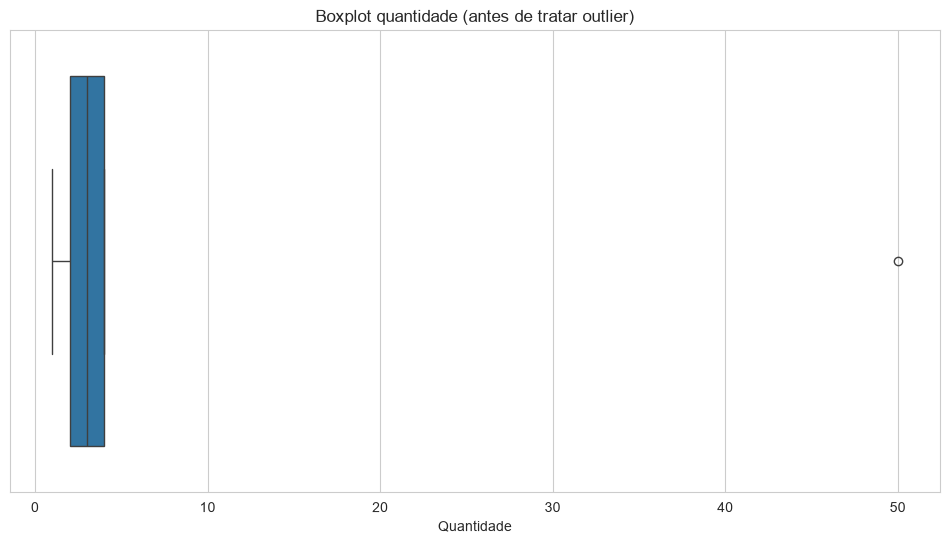

In [20]:
print('Tratando outliers...')
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot quantidade (antes de tratar outlier)')
plt.show()

In [21]:
limite_superior = df_limpo['Quantidade'].mean() + 3 * df_limpo['Quantidade'].std()
df_limpo = df_limpo[df_limpo['Quantidade'] < limite_superior]

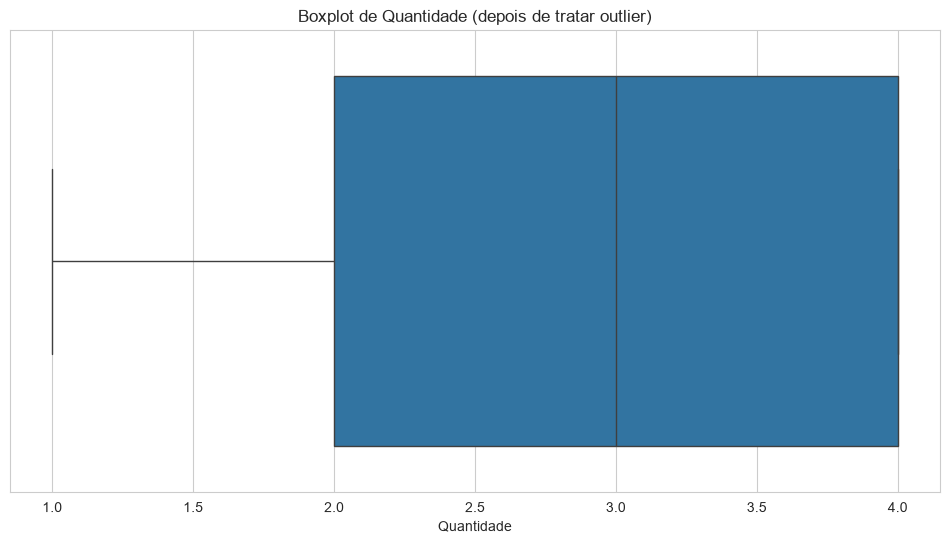

In [22]:
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot de Quantidade (depois de tratar outlier)')
plt.show()

In [23]:
df_limpo.info()
print(f'\nValores ausentes restantes:\n', df_limpo.isna().sum())
print(f'\nLinhas duplicadas restantes: {df_limpo.duplicated().sum()}')

<class 'pandas.DataFrame'>
Index: 97 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       97 non-null     int64         
 1   Data_Compra     97 non-null     datetime64[us]
 2   Cliente_ID      97 non-null     Int64         
 3   Produto         97 non-null     str           
 4   Categoria       97 non-null     str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  97 non-null     float64       
 7   Status_Entrega  97 non-null     str           
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.9 KB

Valores ausentes restantes:
 ID_Pedido         0
Data_Compra       0
Cliente_ID        0
Produto           0
Categoria         0
Quantidade        0
Preco_Unitario    0
Status_Entrega    0
dtype: int64

Linhas duplicadas restantes: 0


In [ ]:
df_limpo['Total_Venda'] = df_limpo['Quantidade'] * df_limpo['Preco_Unitario']

4. Engenharia de Atributos e Extração de Insights

In [24]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado


In [25]:
df_limpo['Total_Venda'] = df_limpo['Quantidade'] * df_limpo['Preco_Unitario']

In [26]:
receita_total = df_limpo['Total_Venda'].sum()
print(f'A receita total da loja foi de: R$ {receita_total:,.2f}')

A receita total da loja foi de: R$ 928,869.00


In [27]:
receita_por_categoria = df_limpo.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False)
print(f'Receita total por categoria: {receita_por_categoria}')

Receita total por categoria: Categoria
Eletrônicos    733495.0
Acessórios     195374.0
Name: Total_Venda, dtype: float64


In [28]:
produto_mais_vendido = df_limpo.groupby('Produto')['Quantidade'].sum().sort_values(ascending=False)
print(f'Total de unidades vendidas por produto: {produto_mais_vendido}')

Total de unidades vendidas por produto: Produto
Smartphone          84.0
Fone de Ouvido      61.0
Smartwatch          59.0
Notebook            32.0
Teclado Mecânico    20.0
Name: Quantidade, dtype: float64


In [29]:
vendas_por_dia = df_limpo.set_index('Data_Compra').resample('D')['Total_Venda'].sum()
print(f'Resumo de vendas por dia (primeiros 5 dias): \n {vendas_por_dia.head()}')

Resumo de vendas por dia (primeiros 5 dias): 
 Data_Compra
2026-06-05     2398.5
2026-06-06        0.0
2026-06-07        0.0
2026-06-08        0.0
2026-06-09    25500.0
Freq: D, Name: Total_Venda, dtype: float64


In [30]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega,Total_Venda
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado,5999.9
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue,25500.0
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue,2398.5
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue,8400.0
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado,3400.0
